# [LAB-08] 3. 이변량 분석 - 연습문제

## #01. 준비작업

### 1. 이전 분석 내용 가져오기

In [6]:
%%capture cap

# 자신의 실습 환경에 맞게 파일 경로 수정하세요
%run "./[LAB-08] PBT - EDAㅣ1-EDA 시작하기(연습문제).ipynb"

### 2. 불러온 내용 확인

- 이전 분석 내역이 잘 로드 되었는지 확인한다.

In [7]:
print("종속변수 :", target)
print("종속변수 유형: " + ("연속형" if target_is_continuous else "명목형"))
print("연속형   :", continuous_cols)
print("명목형   :", nominal_cols)

display(df.head())
display(desc.head())
display(cat_desc.head())

종속변수 : charges
종속변수 유형: 연속형
연속형   : ['age', 'bmi', 'children']
명목형   : ['sex', 'smoker', 'region']


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


,count,mean,std,min,25%,50%,75%,max,rel_diff,rdiff_flag,iqr,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,outliers,outliers_ratio,skew,skew_interpret,kurt,kurt_interpret,log_need
age,1337.000,39.222,14.044,18.000,27.000,39.000,51.000,64.000,0.006,similar,24.000,87.000,-9.000,0,0.000,0,0.000,0,0.000,0.055,symmetric,-1.244,platykurtic,none
bmi,1337.000,30.663,6.100,15.960,26.290,30.400,34.700,53.130,0.009,similar,8.410,47.315,13.675,9,0.007,0,0.000,9,0.007,0.284,symmetric,-0.053,platykurtic,none
children,1337.000,1.096,1.206,0.000,0.000,1.000,2.000,5.000,0.096,similar,2.000,5.000,-3.000,0,0.000,0,0.000,0,0.000,0.937,right tail,0.201,leptokurtic,log1p
charges,1337.000,13279.121,12110.360,1121.874,4746.344,9386.161,16657.717,63770.428,0.415,diff,11911.373,34524.778,-13120.716,139,0.104,0,0.000,139,0.104,1.515,right tail,1.604,leptokurtic,log1p


,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


### 3. 라이브러리 참조

- display는 ipynb에서 사용할 수 있는 전용 출력 함수
- Markdown은 ipynb의 출력 내용에 마크다운을 사용할 수 있게 한다.

In [8]:
from IPython.display import display, Markdown

### 이전 분석 과정에서 설계한 검정 후보

| 종속유형      | 독립유형      | 분석 유형 | 대상 변수                        | 적용 여부 | 비고                |
|-----------|-----------|-------|------------------------------|-------|-------------------|
| 연속형       | 연속형       | 상관분석  | 연속형 독립변수 3종 → charges        | ✅ 적용  | 종속·설명 모두 연속형      |
| 연속형       | 명목형(2집단)  | T검정   | sex, smoker → charges        | ✅ 적용  | sex, smoker가 이진변수 |
| 연속형       | 명목형(3집단+) | ANOVA | region → charges             | ✅ 적용  | region이 4집단       |
| 명목형(2집단)  | 연속형       | T검정   | —                            | ❌ 미적용 | 종속변수 타입이 연속형      |
| 명목형(2집단)  | 명목형(2집단)  | 교차분석  | —                            | ❌ 미적용 | 종속변수 타입이 연속형      |
| 명목형(2집단)  | 명목형(3집단+) | 교차분석  | —                            | ❌ 미적용 | 종속변수 타입이 연속형      |
| 명목형(3집단+) | 연속형       | ANOVA | —                            | ❌ 미적용 | 종속변수 타입이 연속형      |
| 명목형(3집단+) | 명목형(2집단)  | 교차분석  | —                            | ❌ 미적용 | 종속변수 타입이 연속형      |
| 명목형(3집단+) | 명목형(3집단+) | 교차분석  | —                            | ❌ 미적용 | 종속변수 타입이 연속형      |

## #02. 이변량 분석

### 1. 상관분석 (x: 연속형 독립변수 → y: 연속형 종속변수)

#### ▶︎ age(가입자 나이) → charges

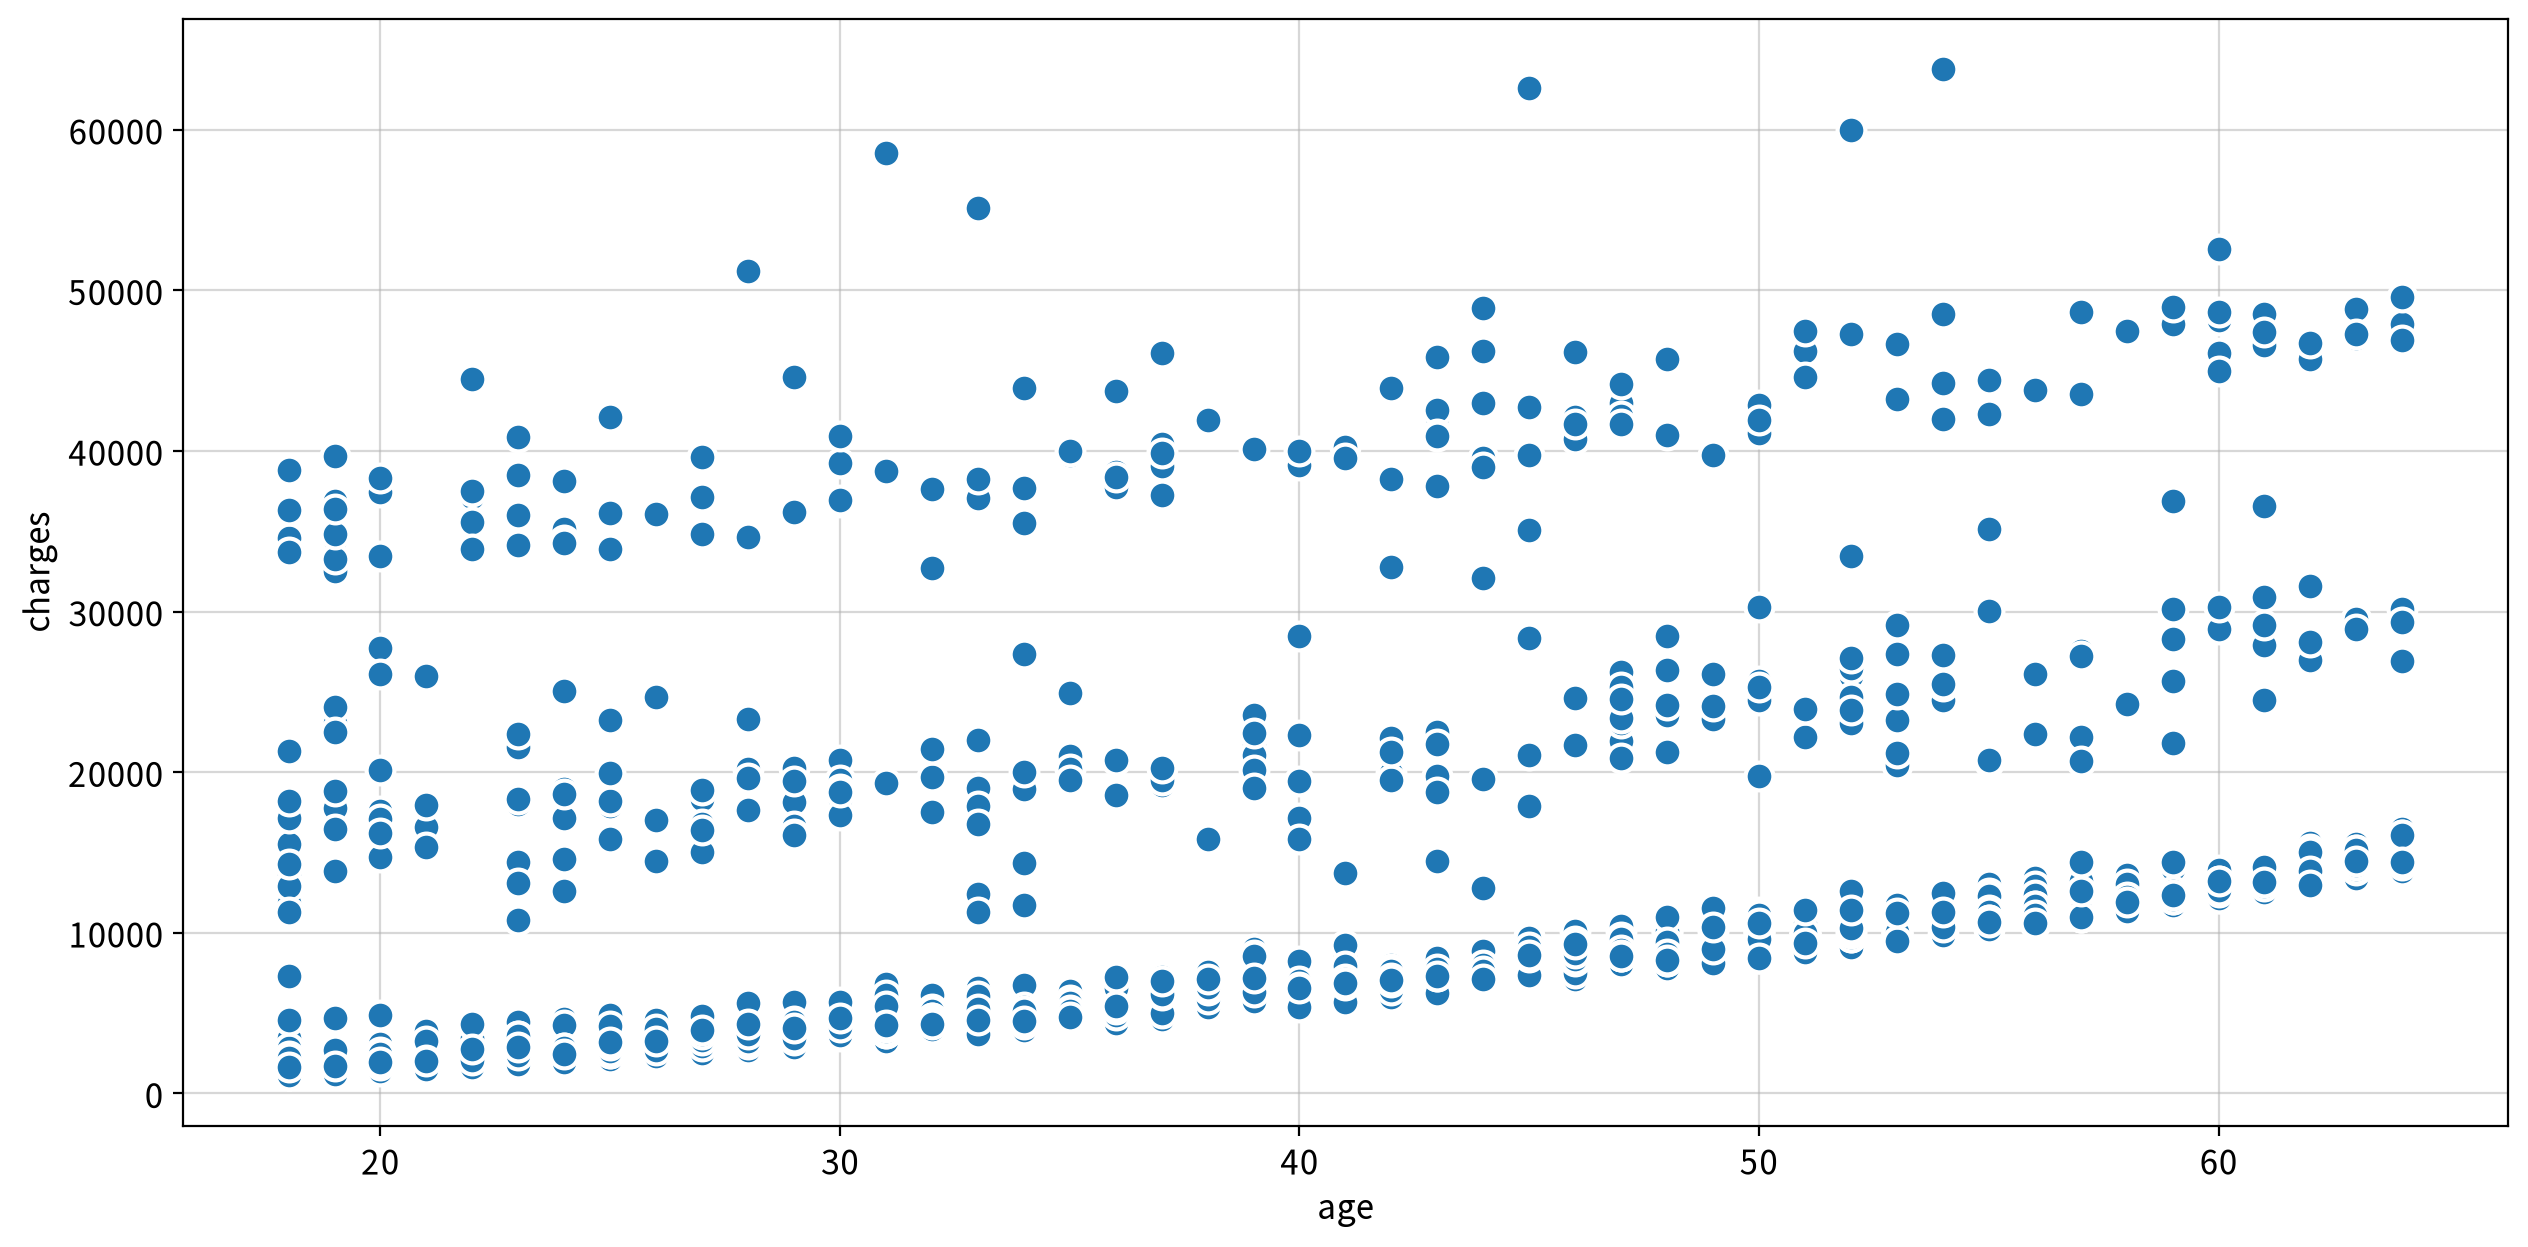

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
age,charges,Spearman,0.533,0.000,Moderate,True,False,False,True,True,True


#### ▶︎ bmi(체질량 지수) → charges

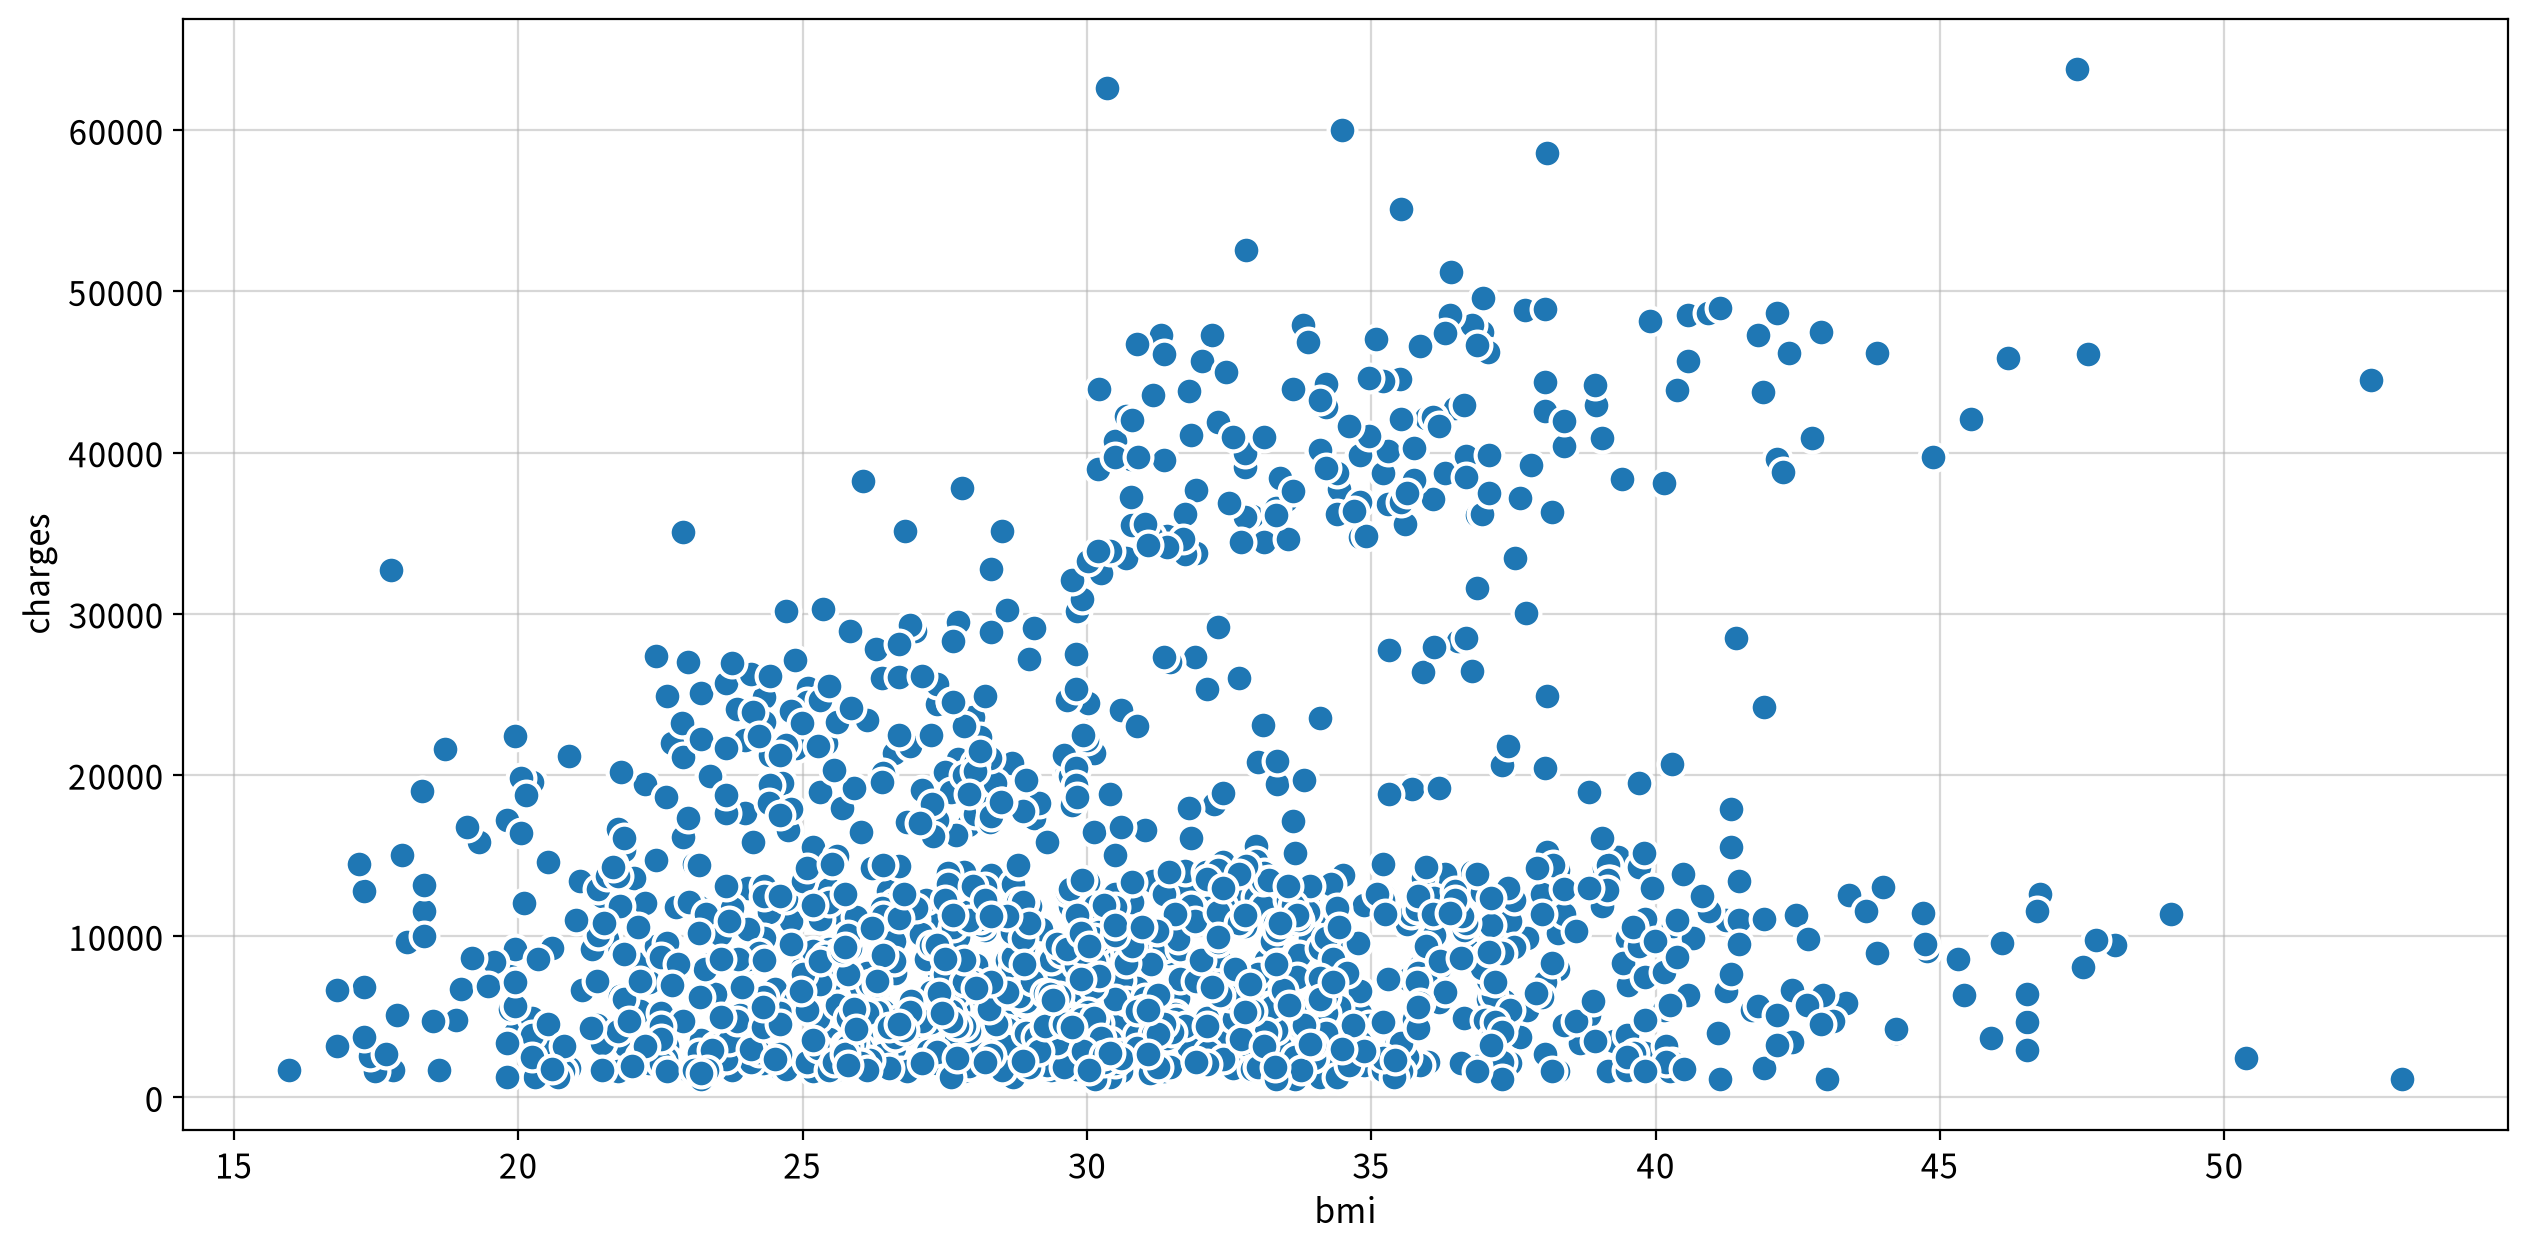

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
bmi,charges,Spearman,0.120,0.000,Weak,True,False,False,True,True,True


#### ▶︎ children(부양 자녀 수) → charges

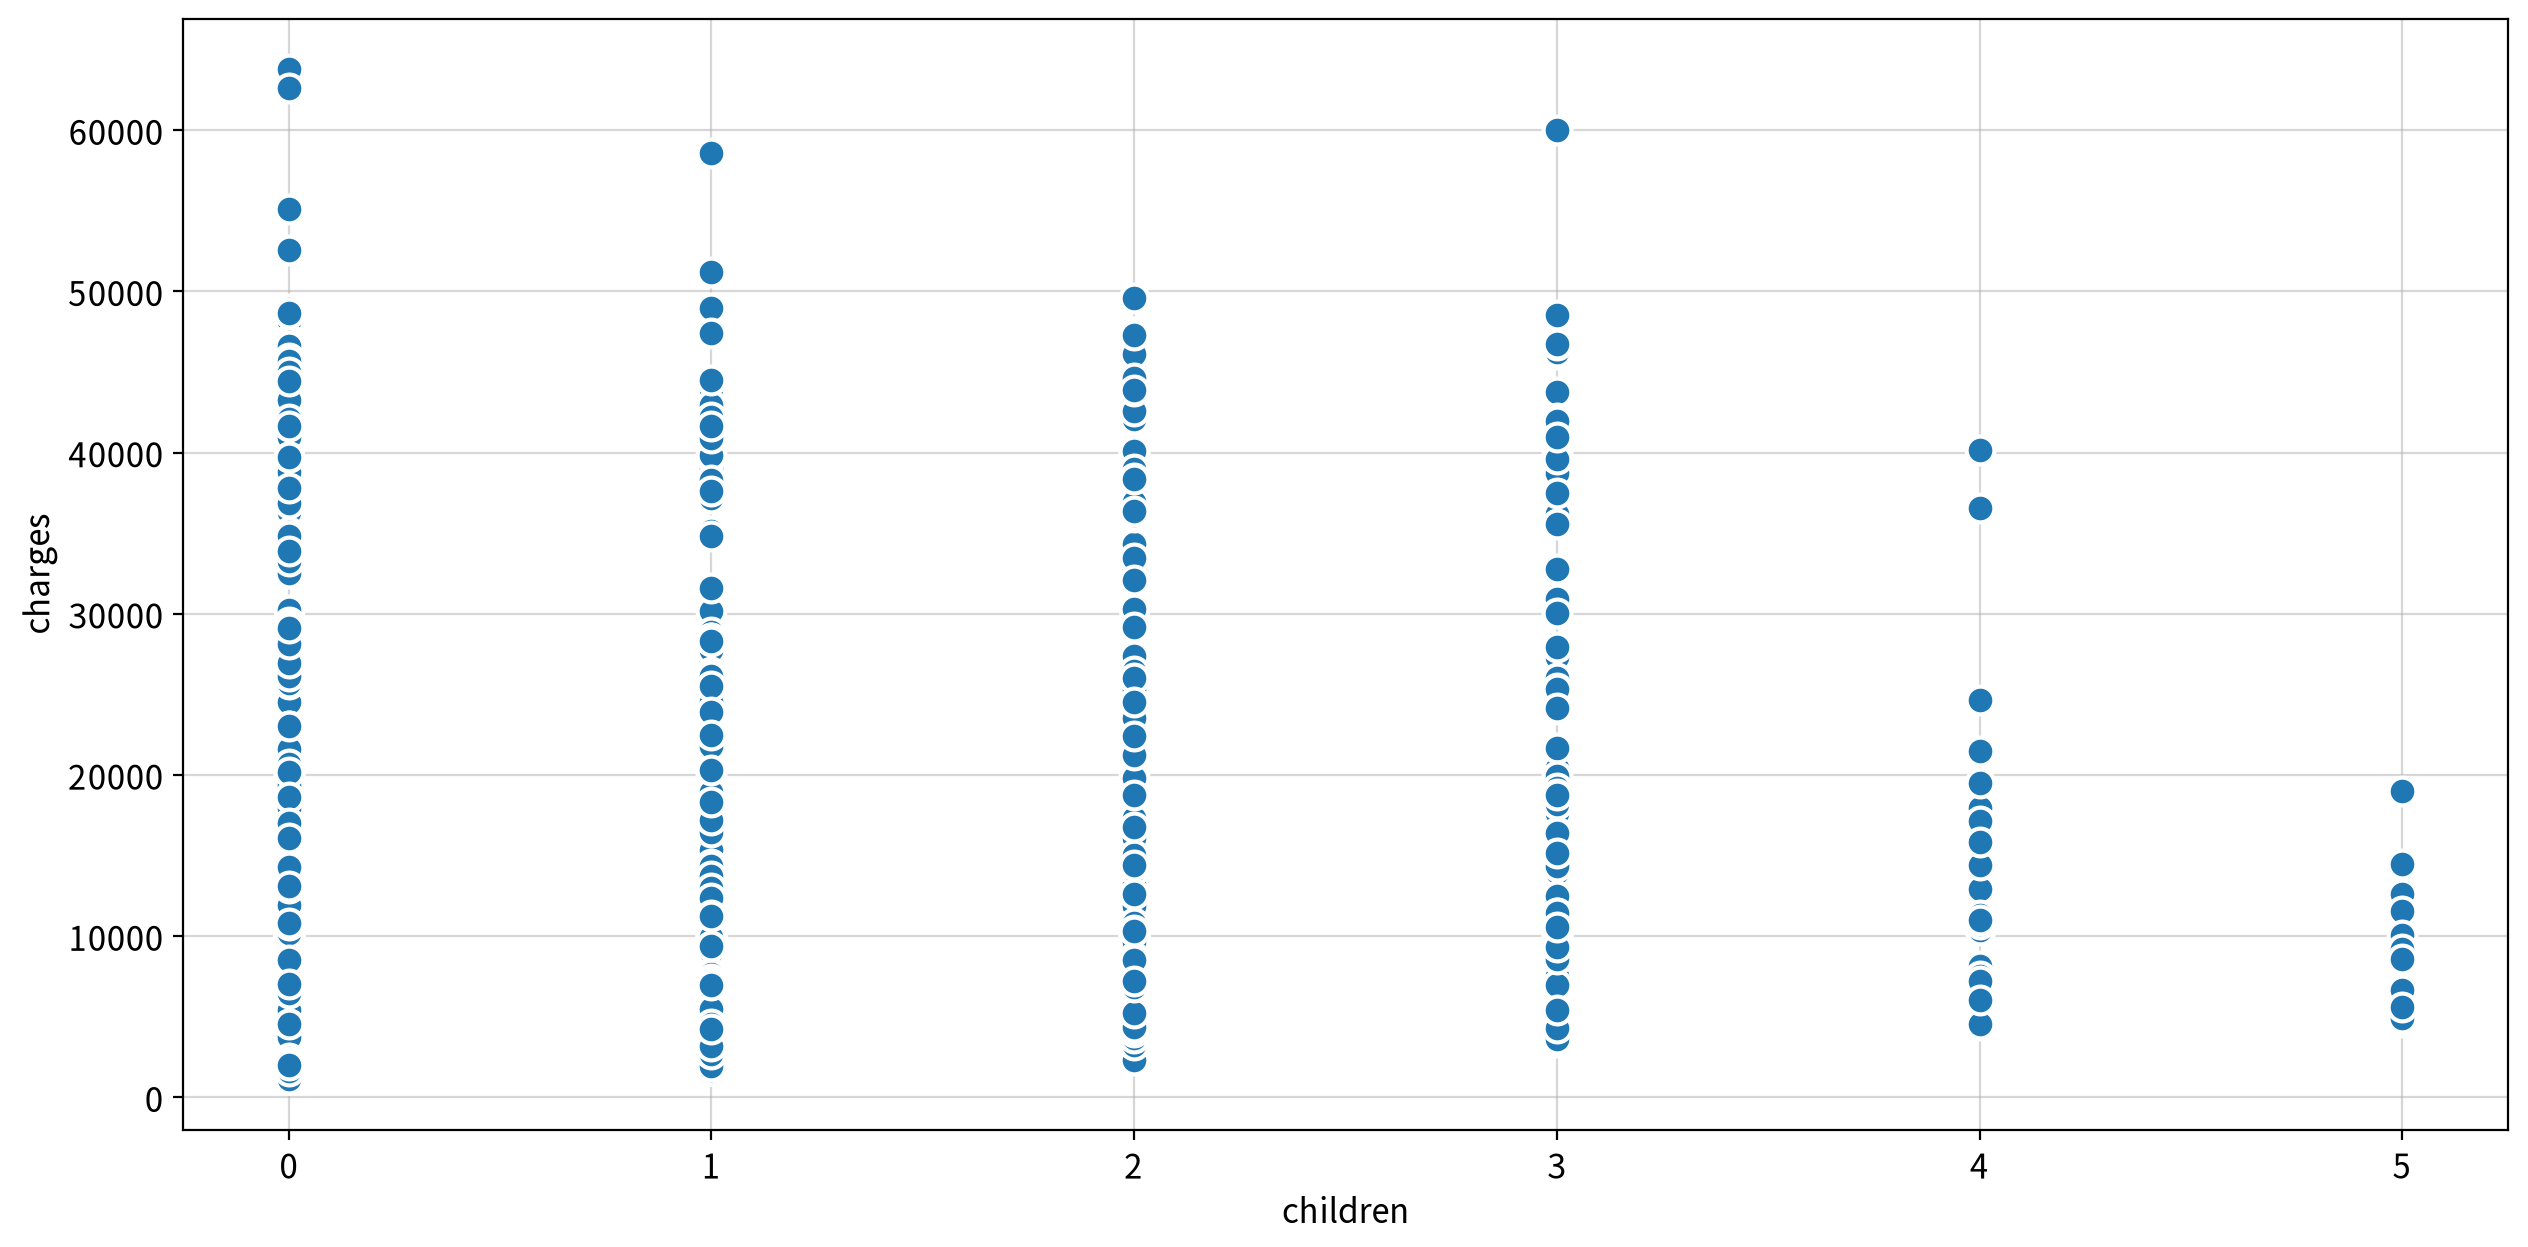

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
children,charges,Spearman,0.132,0.000,Weak,True,False,False,False,False,True


In [9]:
# 연속형 독립변수 이름을 탐색하면서 반복
for f in continuous_cols:
    # 빈 줄 출력용
    print()

    # 분석 단위 제목 출력
    display(Markdown(f"#### ▶︎ {f}({column_means[f]}) → {target}"))
    
    # my_stats는 시각화까지 일괄처리 한다.
    display(my_stats.correlation(df, x=f, y=target))

#### 💡 인사이트 (그래프별 정리)

**`age` → `charges`** — 가입자 나이

| 확인 항목 | 관찰 내용 |
|---|---|
| 선형/비선형 | `linearity=True` → **선형성 충족** |
| 단조성 | ρ=+0.533 → age↑ → charges↑ 양의 단조 증가 |
| 산포 | `normality_x=False`, `normality_y=False` → 두 변수 모두 정규성 미충족 → **Spearman 자동 선택** |
| 이상치 | `influential_outlier=True` → 계수를 왜곡할 수 있는 영향점 존재 |
| **채택 여부** | **채택** — 유의한 양의 중간 상관(Spearman ρ=0.533, Moderate, p<0.05) |

**`bmi` → `charges`** — 체질량 지수

| 확인 항목 | 관찰 내용 |
|---|---|
| 선형/비선형 | `linearity=True` → **선형성 충족** |
| 단조성 | ρ=+0.120 → bmi↑ → charges↑ 방향이나 매우 약함 |
| 산포 | `normality_x=False`, `normality_y=False` → 두 변수 모두 정규성 미충족 → **Spearman 자동 선택** |
| 이상치 | `influential_outlier=True` → 계수를 왜곡할 수 있는 영향점 존재 |
| **채택 여부** | **후보** — 유의하나 Spearman ρ=0.120(**Weak**, \|ρ\|<0.3)로 단독 설명력 미미 |

**`children` → `charges`** — 부양 자녀 수

| 확인 항목 | 관찰 내용 |
|---|---|
| 선형/비선형 | `linearity=False` → **선형성 미충족** |
| 단조성 | ρ=+0.132 → children↑ → charges↑ 방향이나 매우 약함 |
| 산포 | `normality_x=False`, `normality_y=False` → 두 변수 모두 정규성 미충족 → **Spearman 자동 선택** |
| 이상치 | `influential_outlier=False` → 계수를 왜곡하는 영향점 없음 |
| **채택 여부** | **후보** — 유의하나 Spearman ρ=0.132(**Weak**, \|ρ\|<0.3)로 단독 설명력 미미 |

### 2. T-Test (x: 2집단 명목형 독립변수 → y: 종속변수)

- 명목형과 `MEDV`의 그룹 차이를 박스 플롯으로 확인한다


#### ▶︎ sex(성별) → charges

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

female vs. male: Mann-Whitney-Wilcoxon test two-sided, P_val:6.945e-01 U_stat=2.207e+05


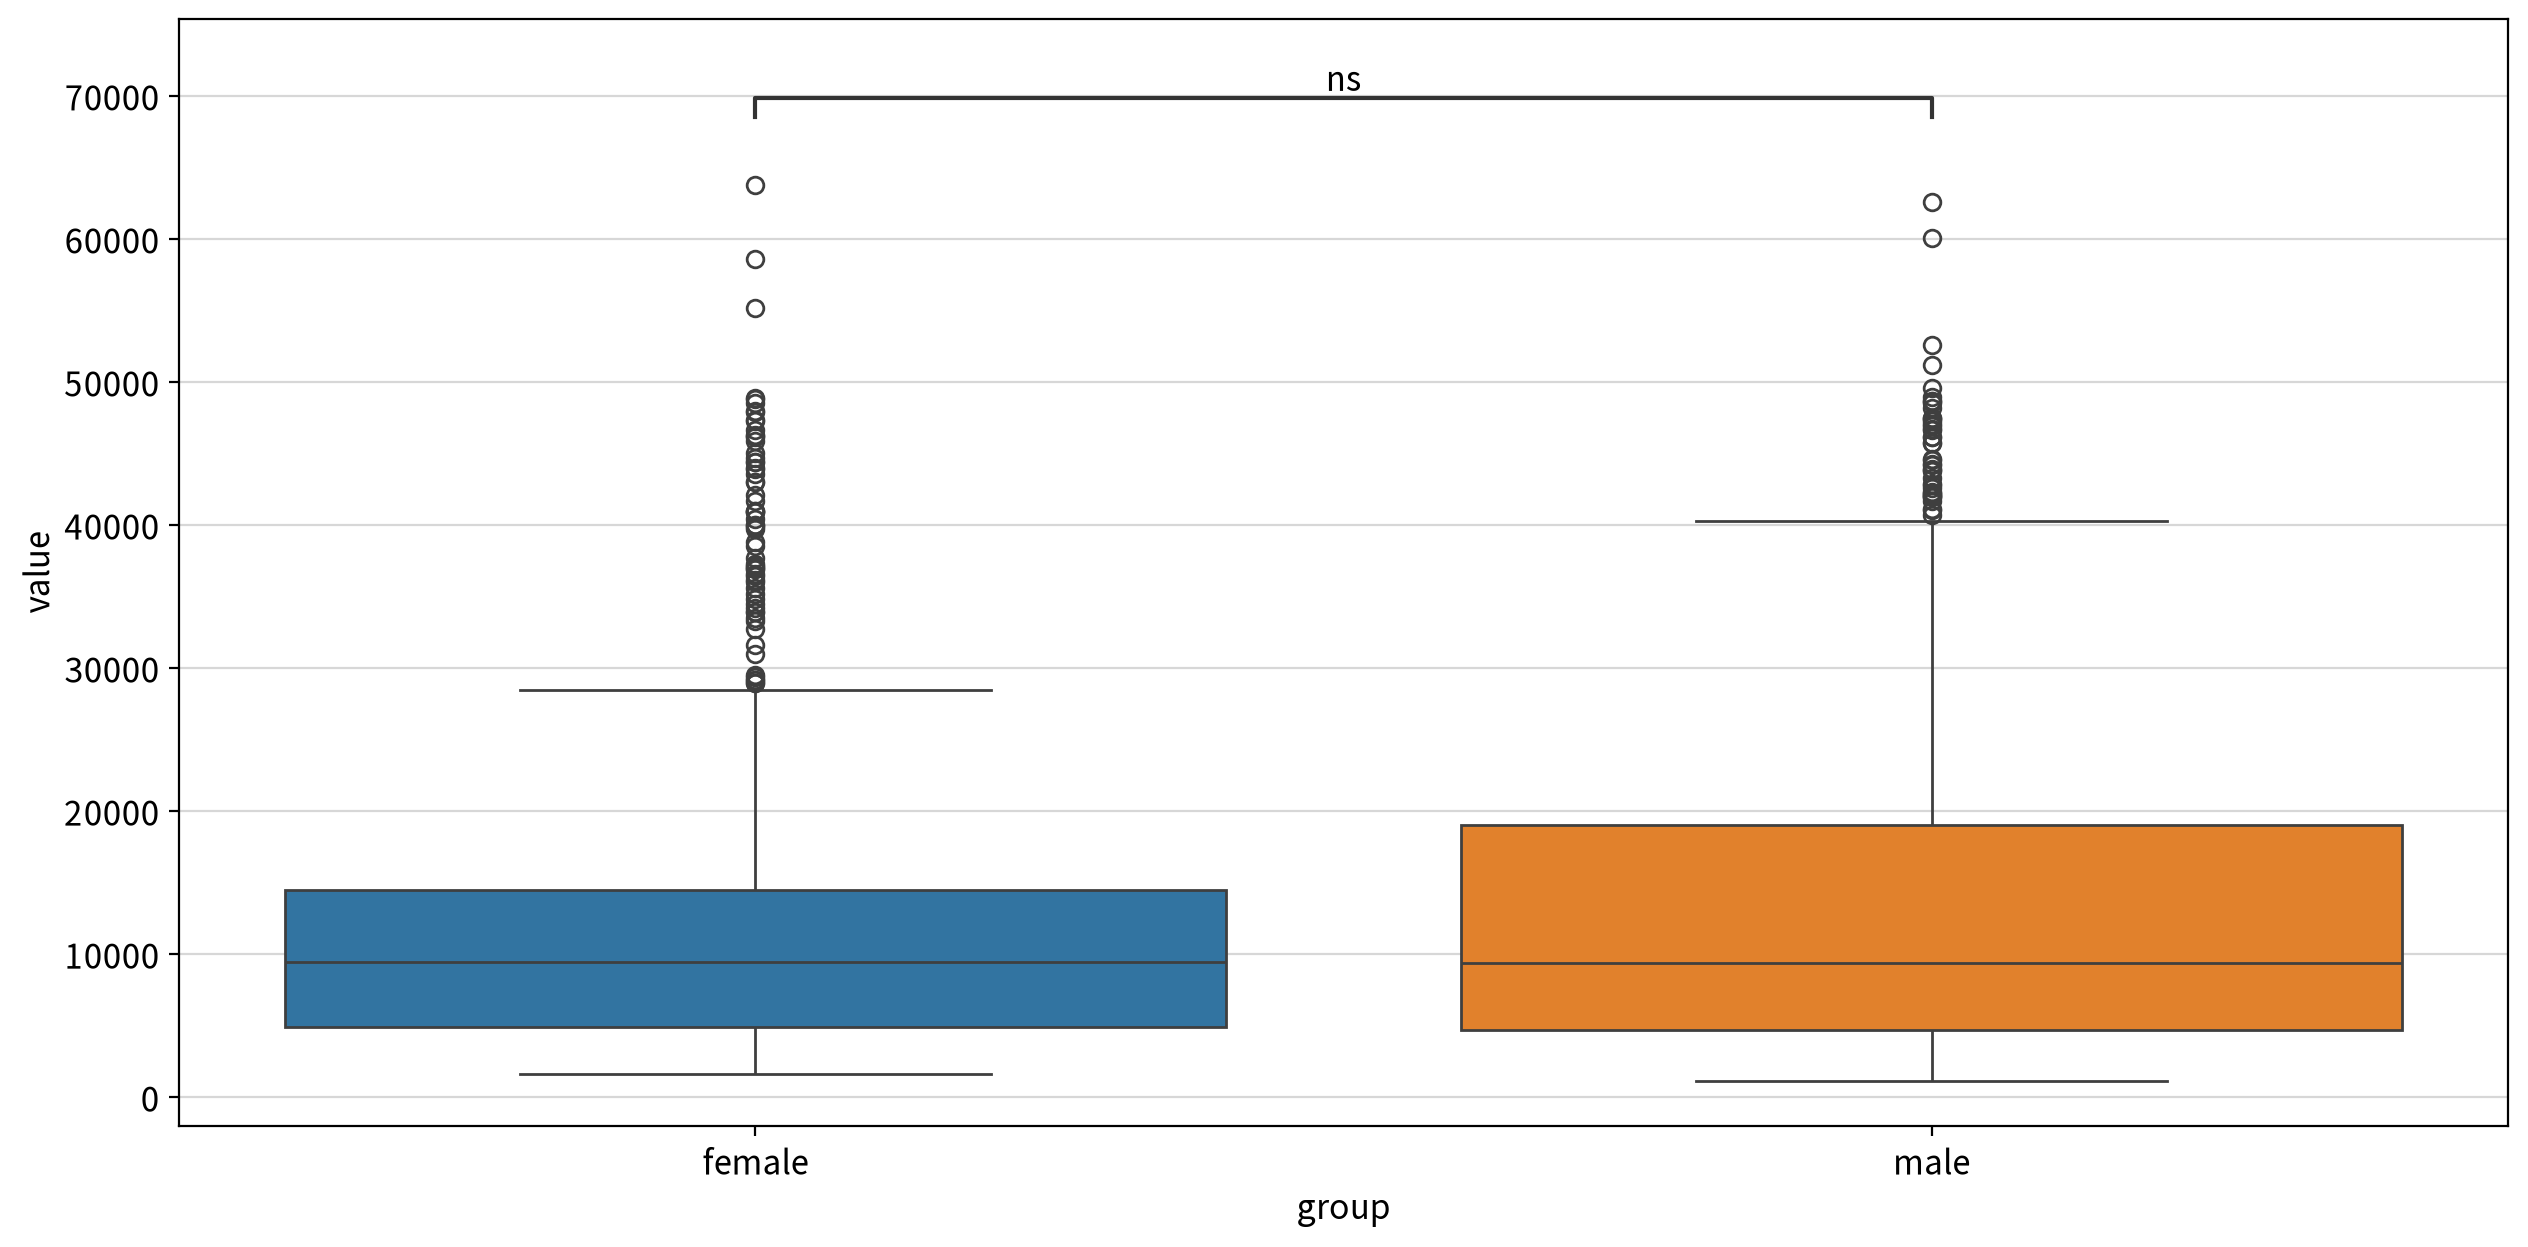

statistic  p-value  significant  \
test                alternative                                    
Mann-Whitney U test two-sided   220652.000    0.695        False   
                    less        220652.000    0.347        False   
                    greater     220652.000    0.653        False   

                                        result  
test                alternative                 
Mann-Whitney U test two-sided    female = male  
                    less         female ≥ male  
                    greater      female ≤ male

#### ▶︎ smoker(흡연여부) → charges

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

no vs. yes: Mann-Whitney-Wilcoxon test two-sided, P_val:5.747e-130 U_stat=7.403e+03


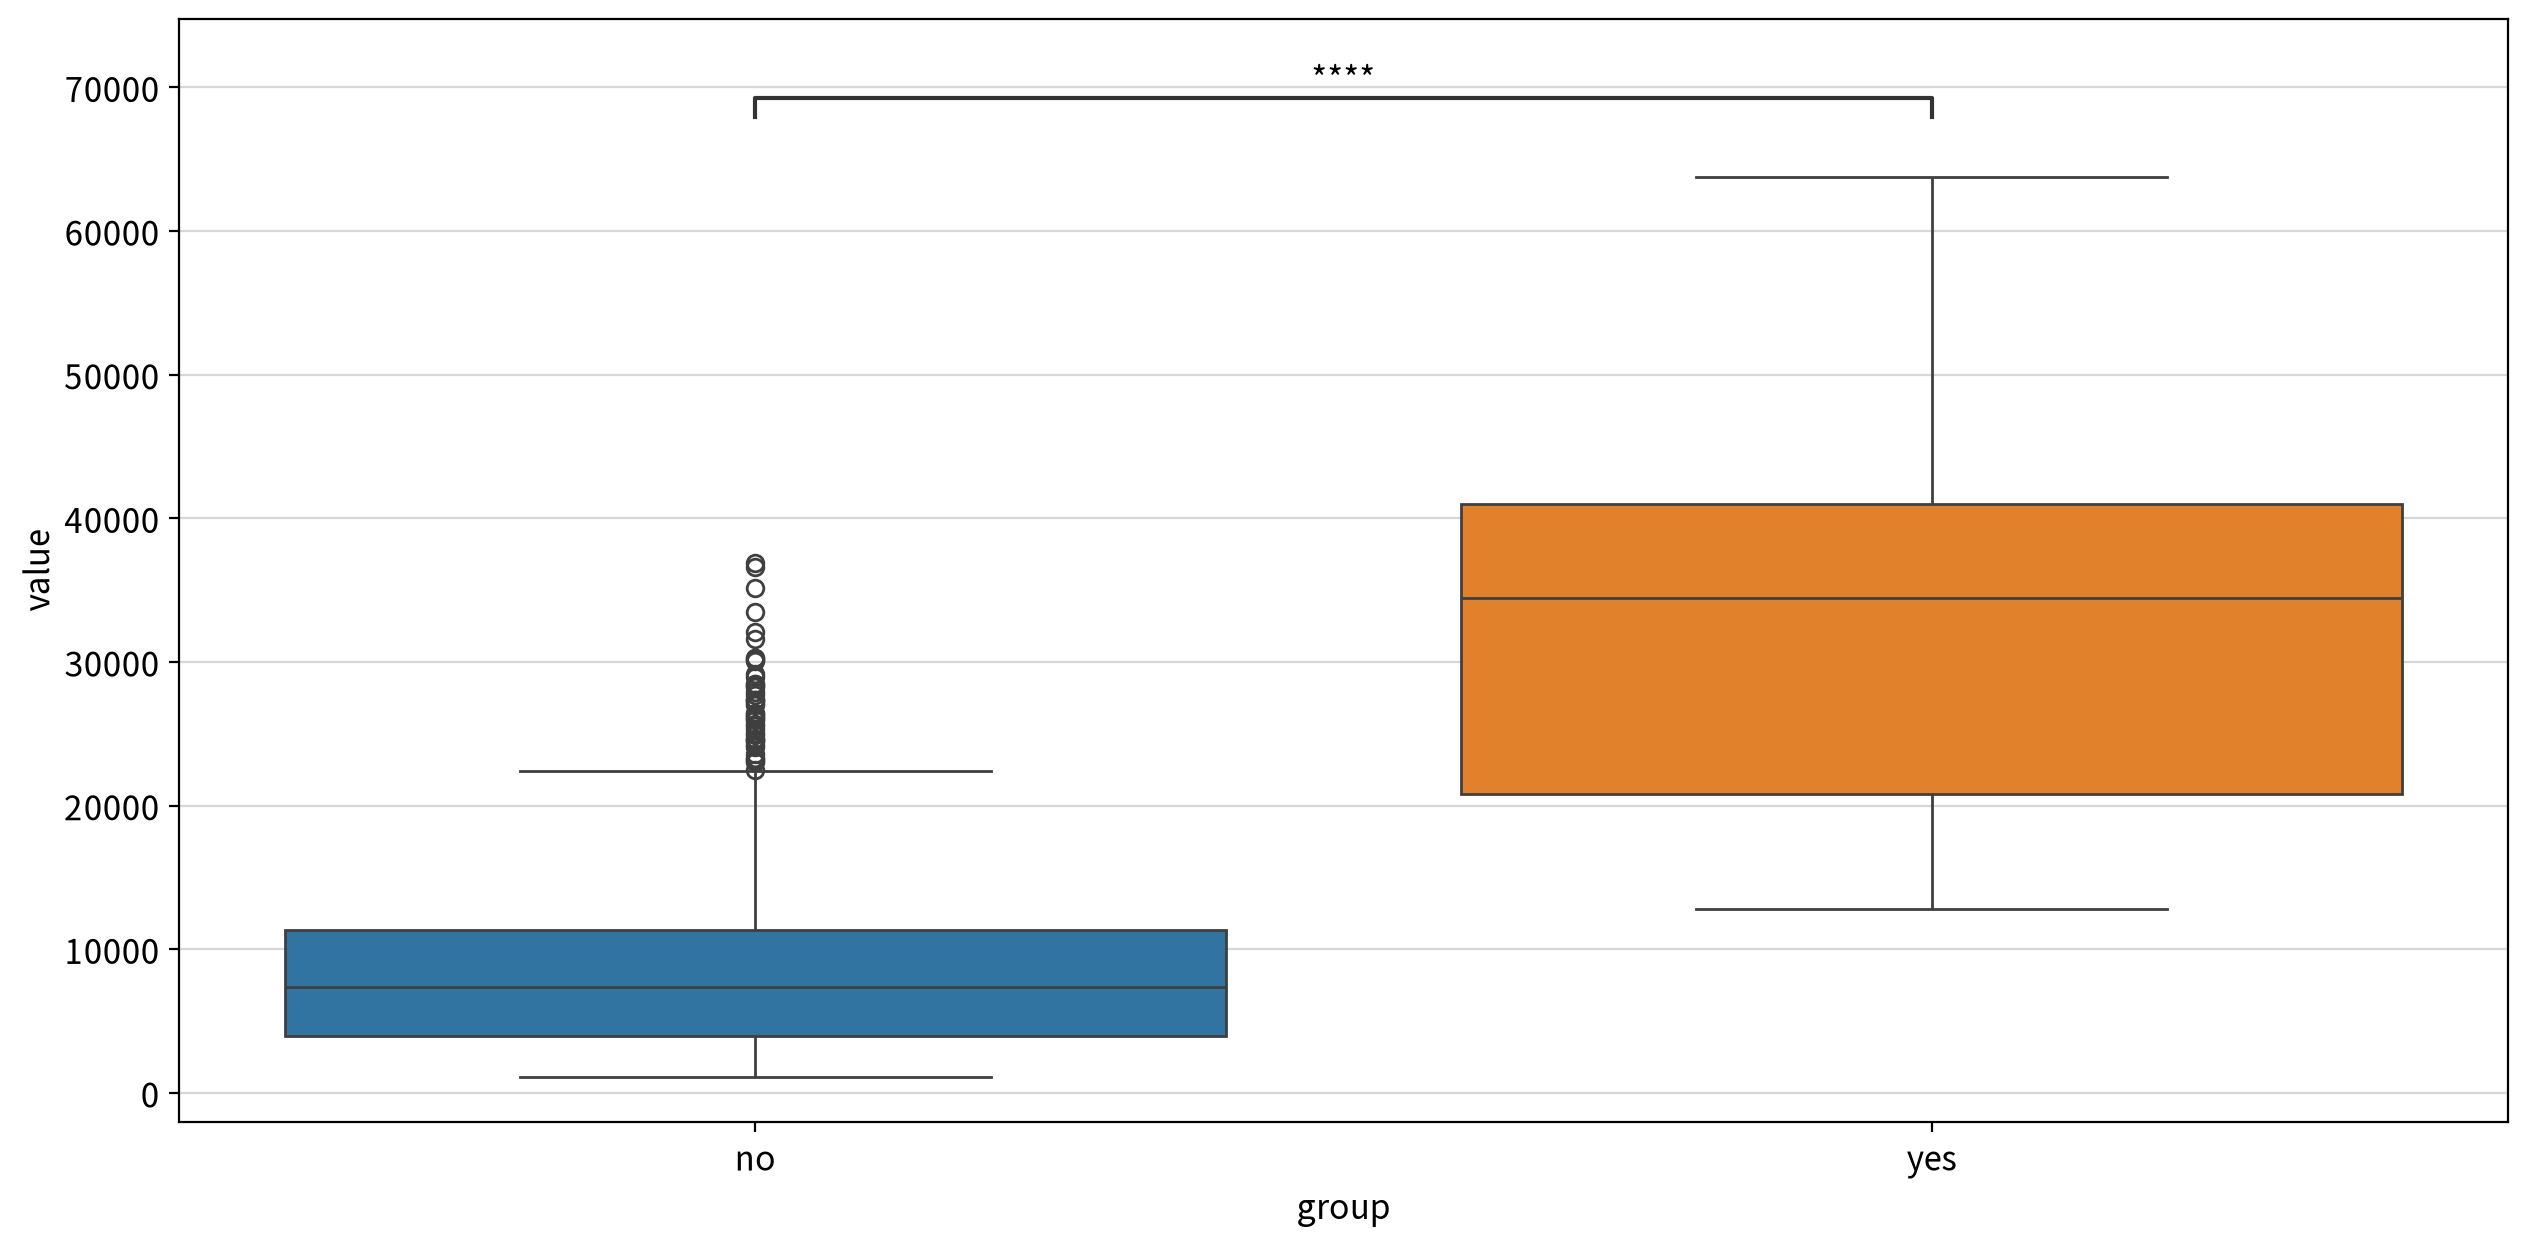

statistic  p-value  significant    result
test                alternative                                           
Mann-Whitney U test two-sided     7403.000    0.000         True  no ≠ yes
                    less          7403.000    0.000         True  no < yes
                    greater       7403.000    1.000        False  no ≤ yes

In [10]:
for n in ['sex', 'smoker']:
    # 빈 줄 출력용
    print()

    # 분석 단위 제목 출력
    display(Markdown(f"#### ▶︎ {n}({column_means[n]}) → {target}"))

    # 수집된 데이터가 long 타입이므로 검정 대상만 wide 타입으로 변환해야 한다.
    wide_df = my_prep.long2wide(origin, hue=n, values=target)
    display(my_stats.test_independent(wide_df, 
                group1=wide_df.columns[0], group2=wide_df.columns[1]))

#### 💡 인사이트 (검정 결과표 기준)

**`sex` → `charges` (명목 2집단)** — 집단 라벨 female, male

| 확인 항목 | 관찰 내용 |
|---|---|
| 적용된 검정 | 정규성 미충족으로 T검정이 아니라 **Mann-Whitney U(비모수)가 채택**됨 (통계량 220652.0) |
| 양측 검정 | **`female = male`(p=0.695 ≥ 0.05)** → 두 집단의 `charges` 분포에 차이가 없음 |
| 단측 검정 | **`female ≥ male`(p=0.347), `female ≤ male`(p=0.653)** → 양쪽 모두 p≥0.05로 방향성 없음 |
| **채택 여부** | **제외** — 두 집단 간 차이가 유의하지 않음 |

**`smoker` → `charges` (명목 2집단)** — 집단 라벨 no, yes

| 확인 항목 | 관찰 내용 |
|---|---|
| 적용된 검정 | 정규성 미충족으로 T검정이 아니라 **Mann-Whitney U(비모수)가 채택**됨 (통계량 7403.0) |
| 양측 검정 | **`no ≠ yes`(p<0.05)** → 두 집단의 `charges` 분포에 차이가 있음 |
| 단측 검정 | **`no < yes`(p<0.05), `no ≤ yes`(p=1.000)** → 흡연자(yes)의 `charges`가 비흡연자(no)보다 큼 |
| **채택 여부** | **채택** — 두 집단 간 차이가 유의함 |

### 3. ANOVA (x: 3개 이상 집단 명목형 독립변수 → 종속변수)

#### ▶︎ region(거주 지역) → charges

,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,welch_anova,region,3,740.416,2.566,0.053,0.007,Negligible


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

northeast vs. northwest: Custom statistical test, P_val:6.962e-01
northwest vs. southeast: Custom statistical test, P_val:8.019e-02
southeast vs. southwest: Custom statistical test, P_val:6.826e-02
northeast vs. southeast: Custom statistical test, P_val:5.122e-01
northwest vs. southwest: Custom statistical test, P_val:9.994e-01
northeast vs. southwest: Custom statistical test, P_val:6.378e-01


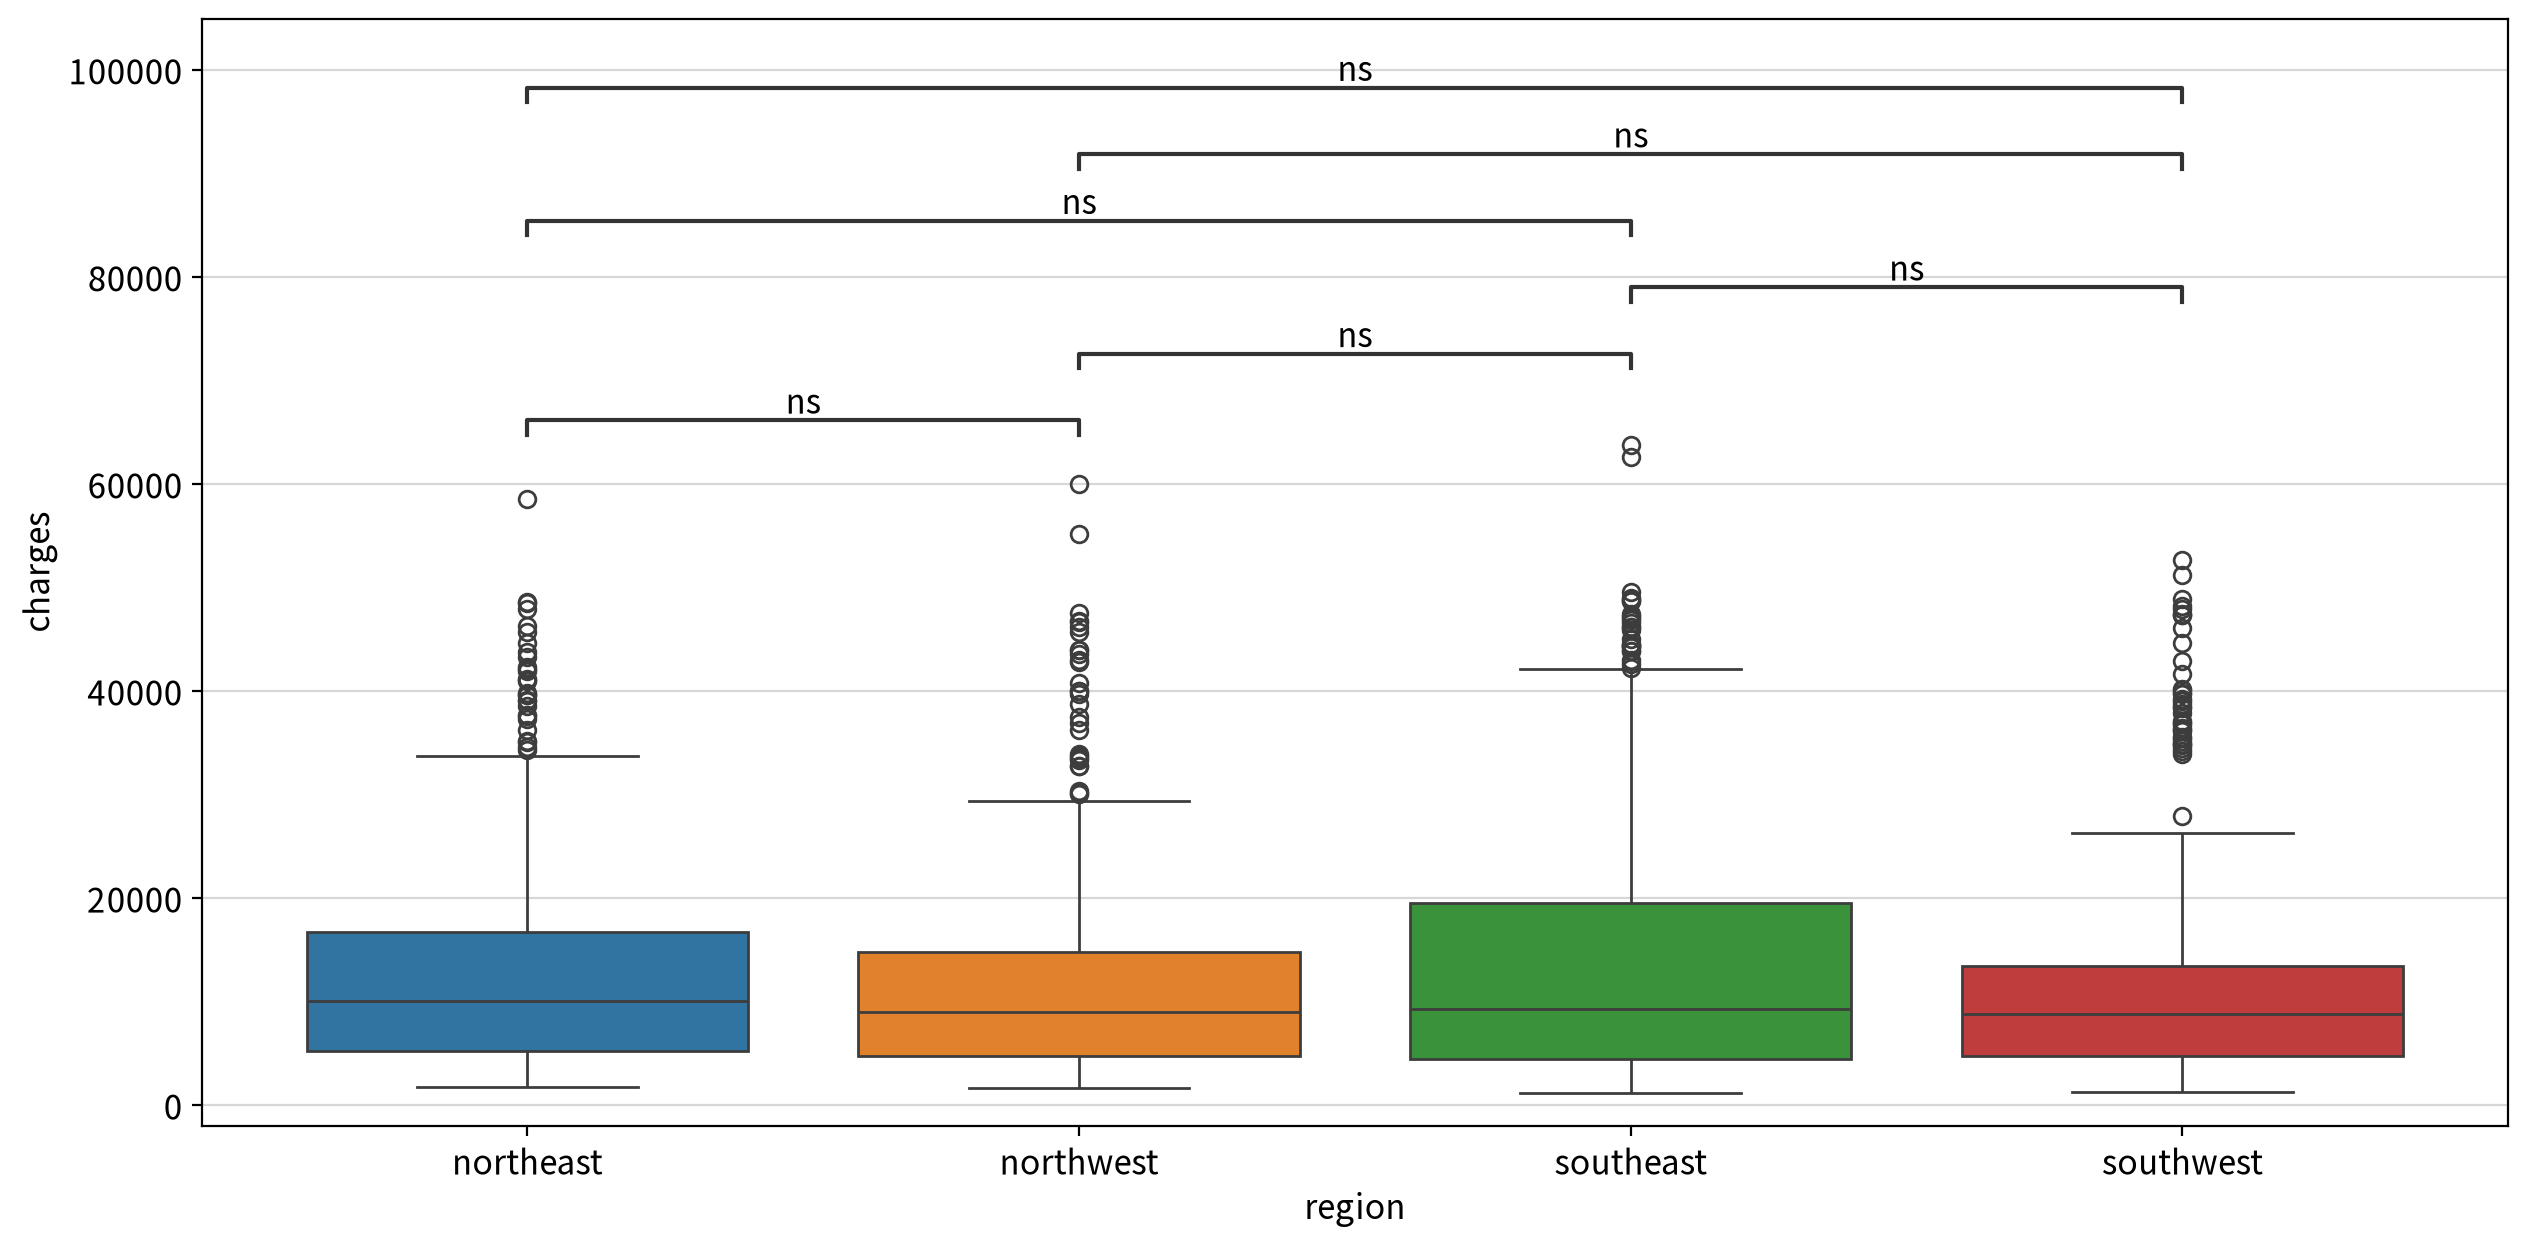

,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,northeast,northwest,13406.385,12450.841,955.544,877.193,1.089,645.827,0.696,0.085,False,Negligible
1,Games-Howell,northeast,southeast,13406.385,14735.411,-1329.027,962.948,-1.380,679.413,0.512,-0.104,False,Negligible
2,Games-Howell,northeast,southwest,13406.385,12346.937,1059.447,895.549,1.183,646.648,0.638,0.093,False,Negligible
3,Games-Howell,northwest,southeast,12450.841,14735.411,-2284.571,956.389,-2.389,677.137,0.080,-0.180,False,Negligible
4,Games-Howell,northwest,southwest,12450.841,12346.937,103.903,888.492,0.117,645.983,0.999,0.009,False,Negligible
5,Games-Howell,southeast,southwest,14735.411,12346.937,2388.474,973.252,2.454,683.096,0.068,0.185,False,Negligible


In [11]:
for n in ['region']:
    # 빈 줄 출력용
    print()

    # 분석 단위 제목 출력
    display(Markdown(f"#### ▶︎ {n}({column_means[n]}) → {target}"))

    # anova 분석은 long 타입으로 바로 투입 가능
    display(my_stats.anova_oneway(origin, y=target, between=n))

    # 사후검정
    display(my_stats.posthoc_oneway(origin, y=target, between=n))

#### 💡 인사이트 (검정 결과표 기준)

**`region` → `charges` (명목 4집단)** — 집단 라벨 northeast, northwest, southeast, southwest

| 확인 항목 | 관찰 내용 |
|---|---|
| 적용된 검정 | 등분산 미충족으로 일반 ANOVA가 아니라 **Welch's ANOVA가 채택**됨 (F=2.566, ddof1=3, ddof2=740.416) |
| 주효과 | **p=0.053 ≥ 0.05** → 네 집단의 `charges` 평균에 유의한 차이가 없음 |
| 효과크기 | **np2=0.007 (Negligible)** |
| 사후검정 | **Games-Howell 6개 쌍 모두 `significant=False`** (최소 p=0.068, northwest–southeast p=0.080), hedges 값 모두 Negligible |
| 집단별 평균 | southeast 14735.411 > northeast 13406.385 > northwest 12450.841 > southwest 12346.937 |
| **채택 여부** | **제외** — 주효과·사후검정 모두 유의하지 않음 |

## #03. 변수 채택 결과 표

| 채택여부 | 변수 | 검정방법 | 유의수준 (p) | 효과크기 | 가정점검 | 비대칭신호 | 근거 |
|---|---|---|---|---|---|---|---|
| ✅ 채택 | smoker | Mann-Whitney U test | $< 0.05$ | 미제공 | 정규성 위배 → 비모수 검정 | 해당 없음 | 집단 간 차이 유의함 (no < yes) |
| ✅ 채택 | age | Spearman | $< 0.05$ | ρ=+0.533 (중간) | 정규성 위배 / 선형성 충족 / 이상치 계수왜곡 있음 | 대칭 / 불필요 | 유의미한 상관 (\|coef\|≥0.3) |
| 🟡 후보 | children | Spearman | $< 0.05$ | ρ=+0.132 (약함) | 정규성 위배 / 선형성 위배 / 이상치 계수왜곡 없음 | 우편향 / log1p 필요 | 유의하나 관계 약함 (\|coef\|<0.3) → **모델링 투입 후 계수 유의성으로 최종 판정** |
| 🟡 후보 | bmi | Spearman | $< 0.05$ | ρ=+0.120 (약함) | 정규성 위배 / 선형성 충족 / 이상치 계수왜곡 있음 | 대칭 / 불필요 | 유의하나 관계 약함 (\|coef\|<0.3) → **모델링 투입 후 계수 유의성으로 최종 판정** |
| ❌ 제외 | region | Welch's ANOVA | $0.053$ | np2=0.007 (Negligible) | 등분산 위배 → Welch 보정 | 해당 없음 | 주효과 유의하지 않음, Games-Howell 6쌍 전부 비유의 |
| ❌ 제외 | sex | Mann-Whitney U test | $0.695$ | 미제공 | 정규성 위배 → 비모수 검정 | 해당 없음 | 집단 간 차이 유의하지 않음 (female = male) |